# BANK TRANSACTION DATA

In [154]:
import pandas as pd
df=pd.read_csv("C:\\Users\\Asus\\OneDrive\\Desktop\\power shheets\\bank_transactions_data_2.csv")
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

**Removing unwanted columns**

In [157]:
df=df.drop(['TransactionID','AccountID','DeviceID','IP Address','MerchantID','Location','CustomerOccupation','LoginAttempts','PreviousTransactionDate','TransactionDate','TransactionType','Channel'], axis=1)
df

,TransactionAmount,CustomerAge,TransactionDuration,AccountBalance
0,14.09,70,81,5112.21
1,376.24,68,141,13758.91
2,126.29,19,56,1122.35
3,184.50,26,25,8569.06
4,13.45,26,198,7429.40
...,...,...,...,...
2507,856.21,33,109,12690.79
2508,251.54,48,177,254.75
2509,28.63,56,146,3382.91
2510,185.97,23,19,1776.91


In [158]:
df.isnull().sum()

TransactionAmount      0
CustomerAge            0
TransactionDuration    0
AccountBalance         0
dtype: int64

In [159]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2507    False
2508    False
2509    False
2510    False
2511    False
Length: 2512, dtype: bool

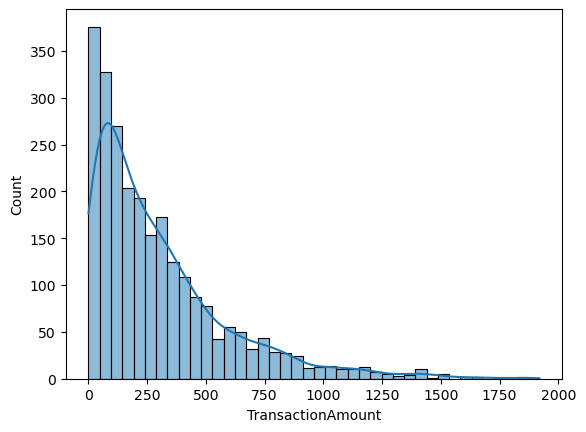

In [160]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(x=df['TransactionAmount'],kde=True)             #Data is normally distributed
plt.show()

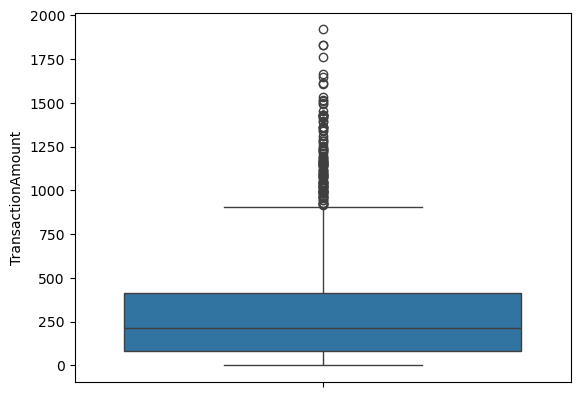

In [161]:
sns.boxplot(df['TransactionAmount']) #There is some outliers but we retrain now
plt.show()

**Applying The Clustering Algorithms**

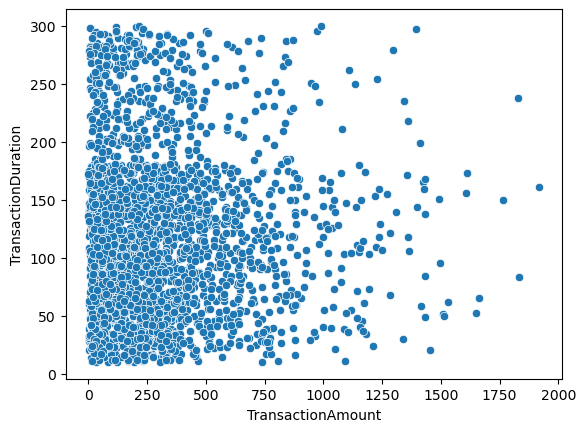

In [163]:
sns.scatterplot(x=df['TransactionAmount'],y=df['TransactionDuration'])
plt.show()

# 1.K-means algorithm

In [165]:
X=df

In [166]:
wcss=[]
for k in range(1,11):
    from sklearn.cluster import KMeans
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
print(wcss)

C:\Users\Asus\AppData\Local\Programs\Orange\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Asus\AppData\Local\Programs\Orange\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Asus\AppData\Local\Programs\Orange\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Asus\AppData\Local\Programs\Orange\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The defa

[38437876953.825615, 10923779575.311523, 4488169657.330822, 2560014861.368497, 1722193133.9096978, 1297714060.5942829, 1035667398.2242844, 825558662.659624, 702253097.5257933, 611832769.587792]


C:\Users\Asus\AppData\Local\Programs\Orange\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


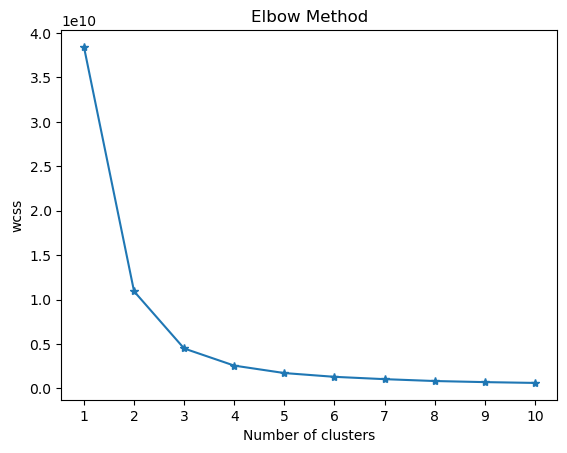

In [167]:
#Using the elbow method
plt.plot(range(1,11),wcss,marker='*')
plt.xticks(range(1,11))
plt.title('Elbow Method')
plt.xlabel("Number of clusters")
plt.ylabel("wcss")
plt.show()

In [168]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=4,init='k-means++',random_state=True)
X['km_clusters']=kmeans.fit_predict(X)
X['km_clusters']

C:\Users\Asus\AppData\Local\Programs\Orange\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


0       3
1       2
2       0
3       1
4       1
       ..
2507    2
2508    0
2509    3
2510    0
2511    0
Name: km_clusters, Length: 2512, dtype: int32

In [169]:
X

,TransactionAmount,CustomerAge,TransactionDuration,AccountBalance,km_clusters
0,14.09,70,81,5112.21,3
1,376.24,68,141,13758.91,2
2,126.29,19,56,1122.35,0
3,184.50,26,25,8569.06,1
4,13.45,26,198,7429.40,1
...,...,...,...,...,...
2507,856.21,33,109,12690.79,2
2508,251.54,48,177,254.75,0
2509,28.63,56,146,3382.91,3
2510,185.97,23,19,1776.91,0


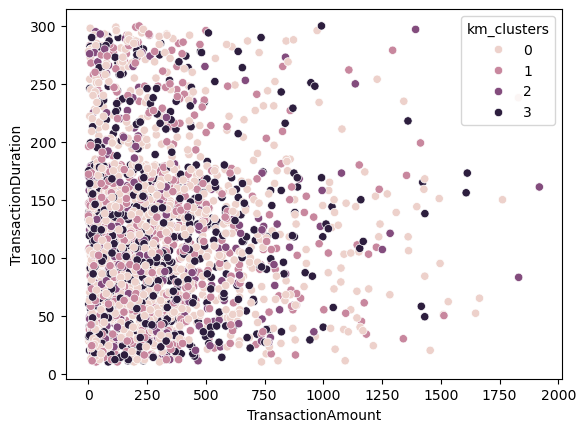

In [170]:
sns.scatterplot(x='TransactionAmount',y='TransactionDuration',hue='km_clusters',data=X)
plt.show()

# 2.Hierachical clustering

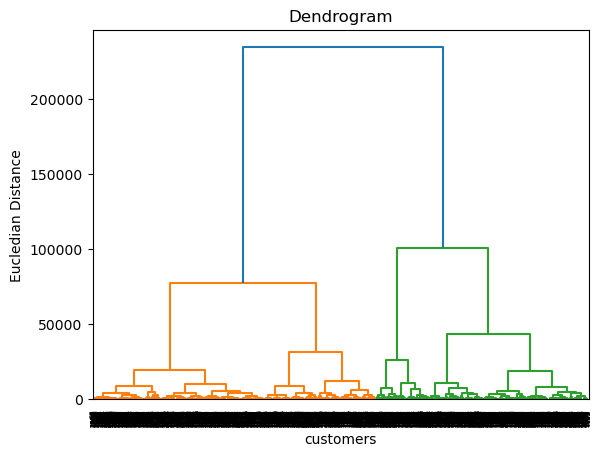

In [210]:
import scipy.cluster.hierarchy as sch
data=sch.linkage(X,method='ward')
dendrogram=sch.dendrogram(data)
plt.xlabel('customers')
plt.ylabel("Eucledian Distance")
plt.title("Dendrogram")
plt.show()

In [212]:
from sklearn.cluster import AgglomerativeClustering
hc=AgglomerativeClustering(n_clusters=4,affinity='euclidean',linkage='ward')
X['h_clusters']= hc.fit_predict(X)
X

C:\Users\Asus\AppData\Local\Programs\Orange\Lib\site-packages\sklearn\cluster\_agglomerative.py:1006: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


,TransactionAmount,CustomerAge,TransactionDuration,AccountBalance,km_clusters,h_clusters
0,14.09,70,81,5112.21,3,1
1,376.24,68,141,13758.91,2,2
2,126.29,19,56,1122.35,0,3
3,184.50,26,25,8569.06,1,0
4,13.45,26,198,7429.40,1,0
...,...,...,...,...,...,...
2507,856.21,33,109,12690.79,2,2
2508,251.54,48,177,254.75,0,3
2509,28.63,56,146,3382.91,3,1
2510,185.97,23,19,1776.91,0,3


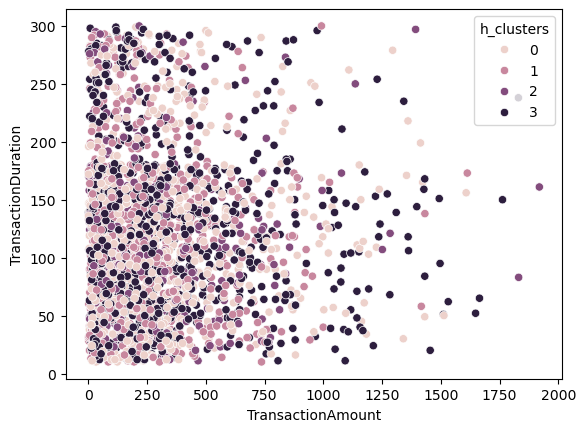

In [214]:
sns.scatterplot(x='TransactionAmount',y='TransactionDuration',hue='h_clusters',data=X)
plt.show()

# DBSCAN(Density Based Spatial Clustering of Applications with Noise)

In [235]:
for r in range(1,10):
    for m in range(1,10):
        from sklearn.cluster import DBSCAN
        dbs=DBSCAN(eps=r,min_samples=m)
        X['dbclusters']=dbs.fit_predict(X)
    if X['dbclusters'].nunique()==4:
        break
print("cps:",r)
print("min:",m)

cps: 9
min: 9


In [237]:
from sklearn.cluster import DBSCAN
bs=DBSCAN(eps=9,min_samples=9)
X['dbclusters']=dbs.fit_predict(X)
X['dbclusters'].nunique()

1

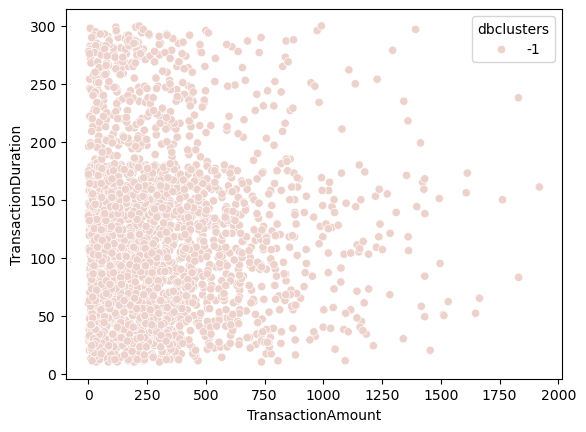

In [229]:
sns.scatterplot(x='TransactionAmount',y='TransactionDuration',hue='dbclusters',data=X)
plt.show()

In [239]:
#In this project k-means and hierachical techniques are best